In [1]:
#Module imports
import pandas as pd
import matplotlib.pyplot as plt
import os
import requests
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import numpy as np


In [2]:
#Read the CSV file containing the dataset information and the photo URL
df = pd.read_csv("KADSI project/fitzpatrick17k.csv")

In [3]:
# Download images from URLs

out_dir = "fitz_images"
os.makedirs(out_dir, exist_ok=True)

ok, fail = 0, 0

# Iterate over the full DataFrame and download each image
for _, row in tqdm(df.iterrows(), total=len(df)):
    img_url = row["url"]
    img_id = row["md5hash"]
    img_path = os.path.join(out_dir, f"{img_id}.jpg")

    # Skip if the image already exists
    if os.path.exists(img_path):
        continue

    try:
        r = requests.get(
            img_url,
            timeout=15,
            headers={"User-Agent": "Mozilla/5.0"}
        )
        if r.status_code == 200 and r.content:
            with open(img_path, "wb") as f:
                f.write(r.content)
            ok += 1
        else:
            fail += 1
    except Exception:
        fail += 1

print("Downloaded:", ok, "| Failed:", fail)


  7%|▋         | 1153/16577 [12:08<2:42:28,  1.58it/s]


KeyboardInterrupt: 

In [ ]:

img_dir = Path(out_dir)

df["path"] = df["md5hash"].apply(lambda x: img_dir / f"{x}.jpg")
df["downloaded"] = df["path"].apply(lambda p: p.exists())

print("Downloaded Images :", df["downloaded"].sum())
print("Missing Images :", (~df["downloaded"]).sum())

# Filter the DataFrame to keep only downloaded images
df = df[df["downloaded"]]

Downloaded Images : 14508
Missing Images : 2069


In [ ]:
df.head()

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum,path,downloaded
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...,fitz_images\5e82a45bc5d78bd24ae9202d194423f8.jpg,True
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...,fitz_images\fa2911a9b13b6f8af79cb700937cc14f.jpg,True
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...,fitz_images\d2bac3c9e4499032ca8e9b07c7d3bc40.jpg,True
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...,fitz_images\0a94359e7eaacd7178e06b2823777789.jpg,True
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...,fitz_images\a39ec3b1f22c08a421fa20535e037bba.jpg,True


Explanation of the columns:

md5hash: file fingerprint/signature, unique key, to be kept to identify the images
fitzpatrick_scale: scale from 1 to 6 to classify skin color (1 being the lightest)
label: dermatological disease, precise diagnosis, multiclass (to be counted)
nine_partition_label: levels of diagnostic certainty (9 major families: inflammatory, benign, dermal, etc.)
three_partition_label: levels of diagnostic certainty (benign, malignant, non-neoplastic)
qc: image quality, NaN = nothing to report
url: image URL
url_alphanum: cleaner URL 

In [ ]:
df["fitzpatrick_scale"].value_counts()


fitzpatrick_scale
 2    4127
 3    2971
 4    2492
 1    2480
 5    1389
 6     557
-1     492
Name: count, dtype: int64

<Axes: xlabel='fitzpatrick_scale'>

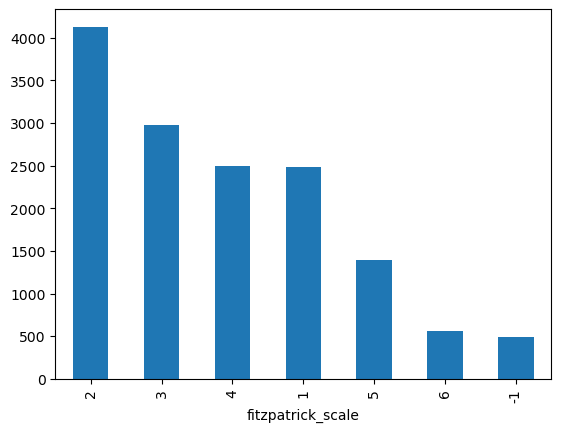

In [ ]:
df["fitzpatrick_scale"].value_counts().plot(kind="bar")

Number of images with scale = -1: 492


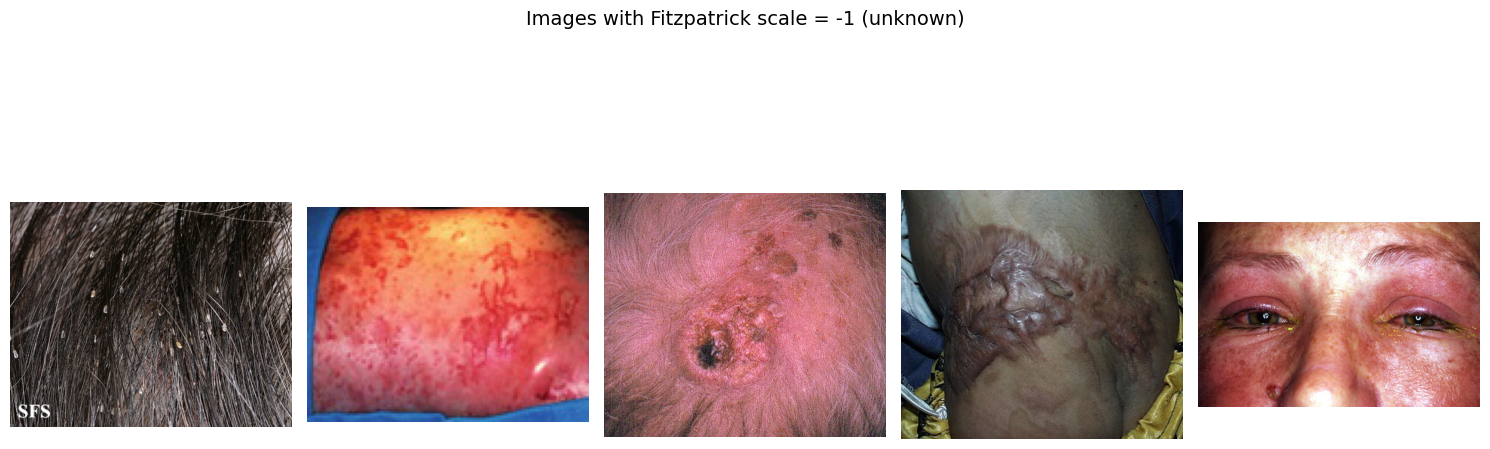

In [ ]:
#Plot images with unknown Fitzpatrick scale (-1)
df_unknown = df[df["fitzpatrick_scale"] == -1]

print("Number of images with scale = -1:", len(df_unknown))

sample = df_unknown.sample(min(5, len(df_unknown)), random_state=0)

fig, axes = plt.subplots(1, 5, figsize=(15, 6))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row["path"])
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Images with Fitzpatrick scale = -1 (unknown)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
df.shape

(14508, 11)

After describing the different columns, we observe that there are no explicit features; it is up to us to choose them.
In image processing, we can choose to work directly on pixel values, depending on whether this is feasible given the image size.

We can apply image processing techniques to extract features (average color, color histograms, texture, edges, etc.).

A pre-trained CNN can be used to extract features.

In [ ]:
# Distribution of labels
df["label"].value_counts()


label
psoriasis                             562
squamous cell carcinoma               521
lichen planus                         443
basal cell carcinoma                  433
allergic contact dermatitis           363
                                     ... 
pilomatricoma                          49
disseminated actinic porokeratosis     49
perioral dermatitis                    49
xanthomas                              47
pustular psoriasis                     42
Name: count, Length: 114, dtype: int64

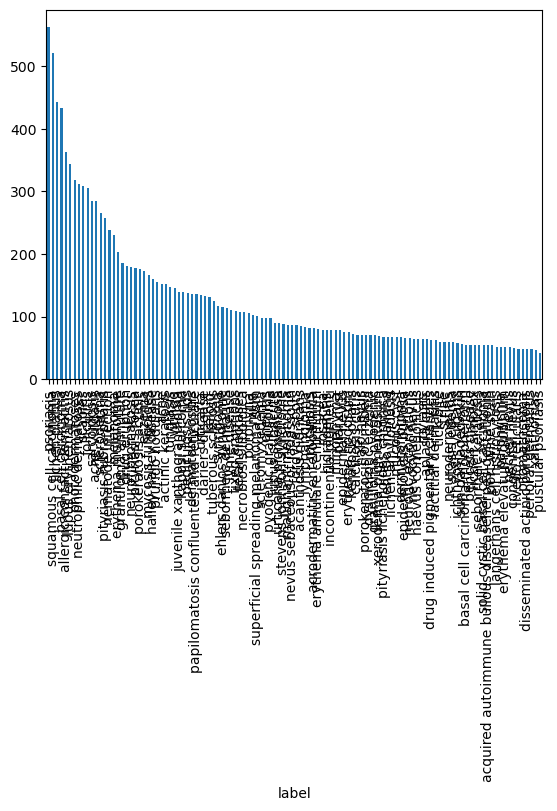

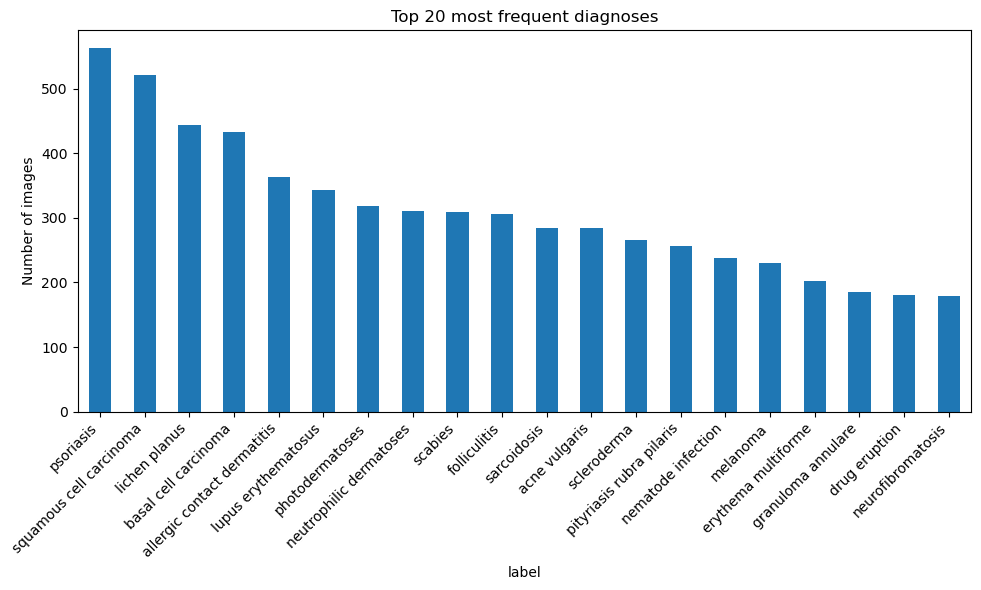

In [ ]:
df["label"].value_counts().plot(kind="bar")

k_values = 20

value_count = df["label"].value_counts().head(k_values)

plt.figure(figsize=(10,6))
value_count.plot(kind="bar")
plt.ylabel("Number of images")
plt.title(f"Top {k_values} most frequent diagnoses")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Since there are 114 labels, it is difficult to plot all of them, so we will select the top-K most represented labels.
This dataset is imbalanced for this class.

We will do the same for the two other columns.

In [ ]:
df["nine_partition_label"].value_counts()

nine_partition_label
inflammatory                    9491
malignant epidermal             1215
genodermatoses                  1065
benign dermal                    927
benign epidermal                 833
malignant melanoma               486
benign melanocyte                185
malignant cutaneous lymphoma     167
malignant dermal                 139
Name: count, dtype: int64

There are 9 descriptors here, as indicated by the name.
The inflammatory descriptor is highly represented compared to the others.

<Axes: xlabel='nine_partition_label'>

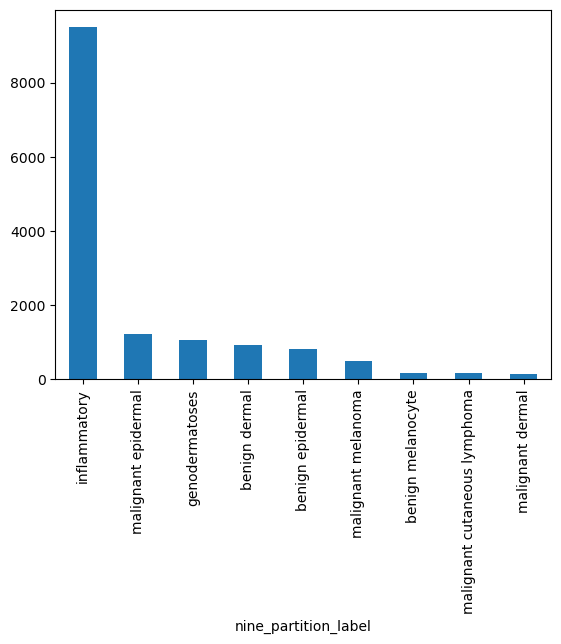

In [ ]:
df["nine_partition_label"].value_counts().plot(kind="bar")

In [ ]:
df["three_partition_label"].value_counts()

three_partition_label
non-neoplastic    10556
malignant          2007
benign             1945
Name: count, dtype: int64

<Axes: xlabel='three_partition_label'>

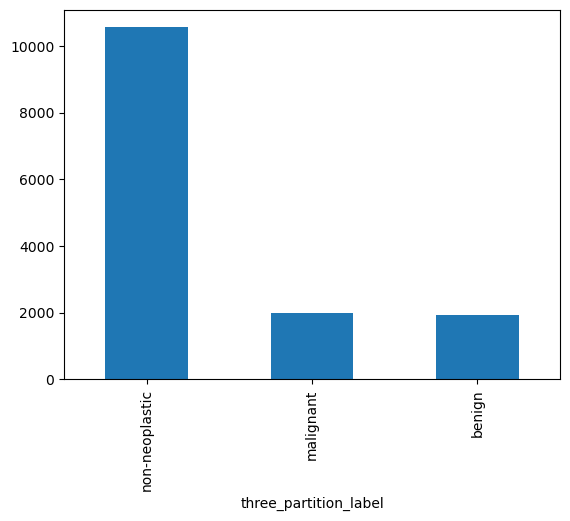

In [ ]:
df["three_partition_label"].value_counts().plot(kind="bar")

Pareil pour ce test, une classe est prédominante par rapport aux autres.

Non-neoplastic : " Qui n'est pas une tumeur"

Conclusion : utiliser Label risque d'être compliqué au vu du nombre de classes (114) bien qu'on pourrait choisir de ne travailler que sur les plus communes, on met cependant de côté les diagnosics plus rare.
Le choix se portera donc sur three ou nine, avec une préférence pour le nine, qui aura une classification plus précise

In [ ]:
#Faire afficher 10 images aléatoires du dataset avec leur label associé

""""
sample = df.sample(min(10, len(df)), random_state=0)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row["path"])
    w, h = img.size

    ax.imshow(img)
    ax.set_title(f"{w} × {h}")
    ax.axis("off")

plt.suptitle("Random Fitzpatrick17k images", fontsize=14)
plt.tight_layout()
plt.show()
"""


'"\nsample = df.sample(min(10, len(df)), random_state=0)\n\nfig, axes = plt.subplots(2, 5, figsize=(15, 6))\naxes = axes.flatten()\n\nfor ax, (_, row) in zip(axes, sample.iterrows()):\n    img = Image.open(row["path"])\n    w, h = img.size\n\n    ax.imshow(img)\n    ax.set_title(f"{w} × {h}")\n    ax.axis("off")\n\nplt.suptitle("Random Fitzpatrick17k images", fontsize=14)\nplt.tight_layout()\nplt.show()\n'

In [ ]:
#Analyse des dimensions des images

img_dir = Path("fitz_images")  
df_use = df.copy()   

# 3) construire la colonne path + filtrer les images présentes
df_use["path"] = df_use["md5hash"].apply(lambda x: img_dir / f"{x}.jpg")
df_use = df_use[df_use["path"].apply(lambda p: p.exists())]

# 4) calcul des tailles (sur max 1000 images)
sizes = []
for p in df_use["path"].sample(min(1000, len(df_use)), random_state=0):
    with Image.open(p) as im:
        sizes.append(im.size)   # (W, H)

sizes = np.array(sizes)

print("Nb images utilisées:", len(sizes))
print("Width  min / median / max :", sizes[:,0].min(), np.median(sizes[:,0]), sizes[:,0].max())
print("Height min / median / max :", sizes[:,1].min(), np.median(sizes[:,1]), sizes[:,1].max())



Nb images utilisées: 1000
Width  min / median / max : 125 456.5 2633
Height min / median / max : 85 380.5 2407


On remarque une grande diversité de taille entre les différentes images, une tâche sera alors de standardiser la taille pour que chaque image ait la même taille

In [ ]:
pd.crosstab(
    df["fitzpatrick_scale"],
    df["three_partition_label"],
    normalize="index"
) * 100



three_partition_label,benign,malignant,non-neoplastic
fitzpatrick_scale,,,
-1,12.601626,18.902439,68.495935
1,15.000000,15.524194,69.475806
2,14.489944,15.846862,69.663194
3,14.405924,14.035678,71.558398
4,12.800963,11.155698,76.043339
5,9.575234,9.359251,81.065515
6,5.924596,8.976661,85.098743


These data shows again the unbalance between, from one side non-neoplastic VS malignant/begign images. This is a commun issue in the biomedical field and it should be taken into account during the pre processing part.

We also notice that darker skin colors are underrepresented in these dataset. Unfortunately, this is also a common issue that we should take into account.


In [ ]:
pd.crosstab(
    df["fitzpatrick_scale"],
    df["nine_partition_label"],
    normalize="index"
) * 100


nine_partition_label,benign dermal,benign epidermal,benign melanocyte,genodermatoses,inflammatory,malignant cutaneous lymphoma,malignant dermal,malignant epidermal,malignant melanoma
fitzpatrick_scale,,,,,,,,,
-1,8.739837,3.455285,0.406504,4.471545,64.024390,1.219512,1.016260,12.195122,4.471545
1,7.459677,5.604839,1.935484,4.879032,64.596774,1.370968,0.645161,9.032258,4.475806
2,7.947662,5.379210,1.163072,5.379210,64.283984,1.066150,0.557306,10.225345,3.998062
3,6.731740,6.193201,1.480983,8.347358,63.211040,1.346348,0.908785,8.650286,3.130259
4,4.494382,7.303371,1.003210,8.828250,67.215088,1.083467,1.605136,6.340289,2.126806
5,3.167747,5.399568,1.007919,12.598992,68.466523,0.935925,1.439885,4.823614,2.159827
6,2.692998,2.513465,0.718133,10.233393,74.865350,0.538600,1.436266,4.847397,2.154399


In [ ]:
(df["fitzpatrick_scale"] == df["fitzpatrick_centaur"]).value_counts(normalize=True)*100
pd.crosstab(df["fitzpatrick_scale"], df["fitzpatrick_centaur"])


fitzpatrick_centaur,-1,1,2,3,4,5,6
fitzpatrick_scale,,,,,,,
-1,255,63,74,31,28,27,14
1,117,2053,259,38,9,3,1
2,241,2024,1348,439,61,10,4
3,188,421,780,1176,363,40,3
4,101,77,265,852,874,299,24
5,36,14,46,107,430,612,144
6,8,16,9,9,28,187,300


Two different ways to describe skin color.

In [ ]:
cls = "psoriasis"
sample = df[df["label"] == cls].sample(10)
